In [1]:
import numpy as np
import pandas as pd
import os
import random

import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from torch.utils.data.dataloader import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import pickle
import matplotlib.pyplot as plt

In [2]:
def seed_everything(seed=100):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
learning_rate= 0.001
epochs= 25

In [4]:
from torchvision import datasets, transforms

# Separate explicit endpoints for the original splits
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform = [transforms.ToTensor()])
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform = [transforms.ToTensor()])
# --- ADDED LINES ---
# Extracting and scaling the training features and labels
x_train = train_dataset.data.float() / 255.0
y_train = train_dataset.targets
x_test = test_dataset.data.float()/255.0
y_test = test_dataset.targets

# --- ADDED LINES FOR FLATTENING ---
# Flatten from [60000, 28, 28] to [60000, 784]
x_train = x_train.view(x_train.size(0), -1)
x_test  = x_test.view(x_test.size(0), -1)

x_test.shape

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.12MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.5MB/s]


torch.Size([10000, 784])

In [5]:
'''technically, we do not need to onehot encode our ydata as the loss function
CrossEntropyLoss accepts target lables encoded in class form AND onehot encoded
form. I am choosing to OneHotEncode because we may want to perform label
smoothing or other transforms later on.'''

y_train = F.one_hot(y_train, num_classes=10)
y_test  = F.one_hot(y_test, num_classes=10)

In [6]:
from torch.utils.data.dataloader import DataLoader

class data_loader(torch.utils.data.Dataset):
  def __init__(self, x_tensor, y_tensor):
    self.x= x_tensor
    self.y= y_tensor

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]

#creating a train dataset object, test dataset object

train_data= data_loader(x_train, y_train)
test_data = data_loader(x_test, y_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [7]:
x_train.shape

torch.Size([60000, 784])

In [8]:
import torch.nn as nn
import torch.nn.functional as F
class neural_net(nn.Module):
  def __init__(self, num_of_features, num_of_output_classes):
    super().__init__()


    self.fc1 = nn.Linear(784, 16)
    self.left_fc1 = nn.Linear(16, 8)
    self.left_fc2 = nn.Linear(8, 8)

    self.right_fc1 = nn.Linear(16, 12)
    self.right_fc2 = nn.Linear(12, 8)

    self.output_layer = nn.Linear(16, 10)


  def forward(self,x):
    x = F.relu(self.fc1(x))
    xleft = F.relu(self.left_fc1(x))
    xleft2 = F.relu(self.left_fc2(xleft))
    xleft = xleft + xleft2
    xright = F.relu(self.right_fc1(x))
    xright = F.relu(self.right_fc2(xright))

    combination = torch.cat((xleft, xright), dim=1)

    out = self.output_layer(combination)
    return out

model =neural_net(784, 10)

In [9]:
lossfn= nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
def compute_test_accuracy(test_loader, model):
  total =0
  correct =0

  with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      batch_features.shape
      output= model(batch_features)
      _, predicted =torch.max(output, 1)

      # Convert one-hot encoded batch_labels to class indices for comparison
      correct+=(predicted==torch.argmax(batch_labels, 1)).sum().item()
      total += batch_labels.shape[0]


  accuracy= correct/total
  print(f"Accuracy: {accuracy}")
  return accuracy

In [11]:
epoch_losses = []
testing_accuracy = [] # List to store average loss per epoch
model.eval()

for epoch in range(epochs):
  testing_accuracy.append(compute_test_accuracy(test_loader, model))
  total_epoch_loss= 0
  for batch_features, batch_labels in train_loader:
    optimizer.zero_grad()
    outputs= model(batch_features)
    loss= lossfn(outputs, batch_labels.float())
    total_epoch_loss+= loss.item()
    #backward pass to calculate all the gradients
    loss.backward()
    #updating params.
    optimizer.step()
  average_loss= total_epoch_loss/len(train_loader)

  epoch_losses.append(average_loss)


Accuracy: 0.0968
Accuracy: 0.8142
Accuracy: 0.8308
Accuracy: 0.8357
Accuracy: 0.8455
Accuracy: 0.8378
Accuracy: 0.8422
Accuracy: 0.8494
Accuracy: 0.8493
Accuracy: 0.8559
Accuracy: 0.8514
Accuracy: 0.8573
Accuracy: 0.8571
Accuracy: 0.854
Accuracy: 0.8604
Accuracy: 0.8609
Accuracy: 0.861
Accuracy: 0.8592
Accuracy: 0.8578
Accuracy: 0.8596
Accuracy: 0.8613
Accuracy: 0.8641
Accuracy: 0.8537
Accuracy: 0.8576
Accuracy: 0.86


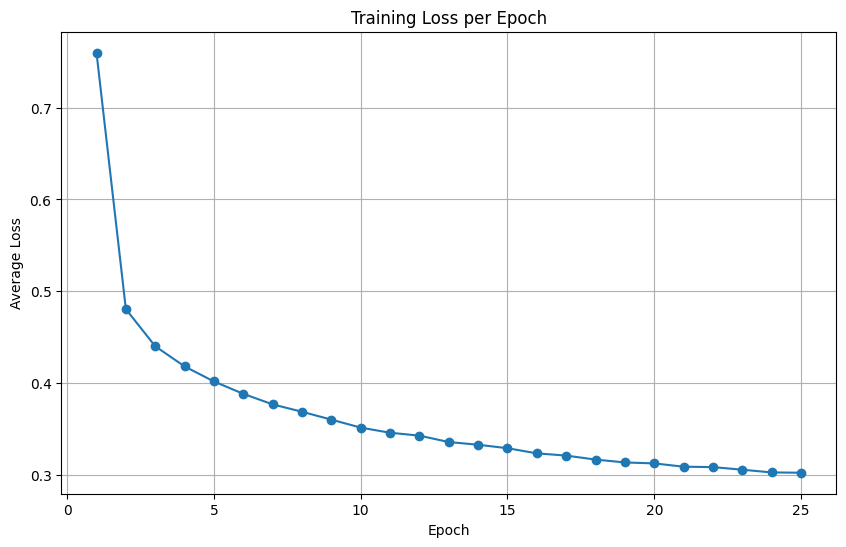

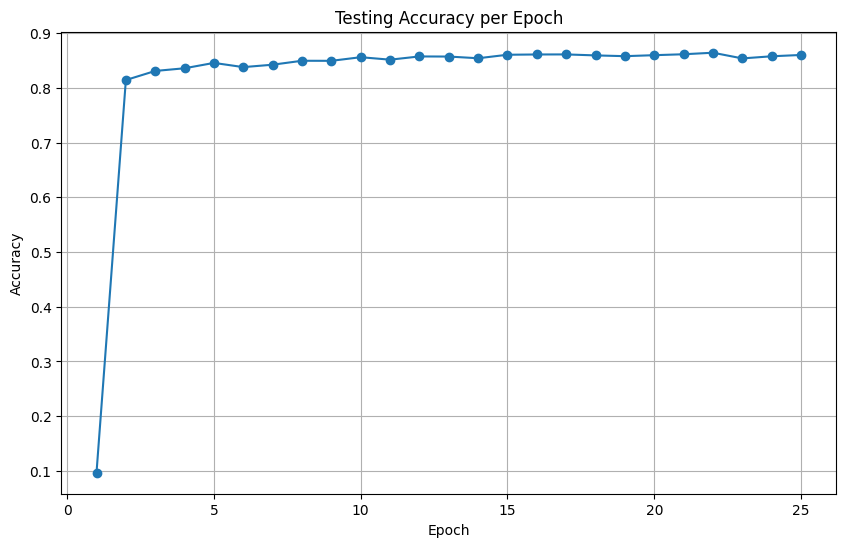

In [12]:
#plotting the epoch losses:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), epoch_losses, marker='o', linestyle='-')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), testing_accuracy, marker='o', linestyle='-')
plt.title('Testing Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [13]:
model.eval()
all_predictions = []
with torch.no_grad():
    for batch_features, _ in test_loader:
        outputs = model(batch_features)
        _, predicted_batch = torch.max(outputs, 1)
        all_predictions.append(predicted_batch)

predicted = torch.cat(all_predictions, dim=0)

# Convert predictions to a pandas DataFrame to save it to file
submission_df = pd.DataFrame({'ImageId': range(1, len(predicted) + 1), 'Label': predicted.numpy()})

# Save the DataFrame to a CSV file
submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)
print("File successfully created: ")
print(submission_df.head())

File successfully created: 
   ImageId  Label
0        1      9
1        2      2
2        3      1
3        4      1
4        5      6


In [15]:
import pickle

# Define the filename for your saved weights
weights_filename = 'model_weights.pkl'

# Save the model's state_dict using pickle
with open(weights_filename, 'wb') as f:
    pickle.dump(model.state_dict(), f)

print(f"Final Training Loss: {epoch_losses[-1]:.4f}")
print(f"Final Testing Accuracy: {testing_accuracy[-1] * 100:.2f}%")

Final Training Loss: 0.3025
Final Testing Accuracy: 86.00%
